<a href="https://colab.research.google.com/github/ichika-yay/Economics-Brawl-Stars/blob/main/%E7%84%A1%E7%95%B0%E6%9B%B2%E7%B7%9A%E7%90%86%E8%AB%96(%E7%84%A1%E9%A3%BD%E5%92%8C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**同為藥物與調劑的狂熱者，藥師拜倫很愛去逛保力的酒牆。琳瑯滿目的瘋狂飲料，讓拜倫擁有無數種消費組合和結構。**

**模型A：無飽和/正常模型（多多益善）**<br>保力向拜倫推薦了清甜甘口的「天堂酒」和淡口微酸的「潤酸釀」。兩款酒味道較溫和，且神奇的不會隨著攝取量提高感到膩口乏味。

**1.計算最適消費組合：** 使用者輸入經濟參數後，使用Cobb-Douglas效用函數 (U(X,Y) = X^a·Y^b (a,b = 偏好權重)) <br>計算最大效用值，並用MRS=Px/Py進行數理驗證

In [ ]:
import numpy as np
from scipy.optimize import minimize
print("=====保力酒吧開張=====")
print("請輸入今晚的酒吧經濟參數:")
def correct_input(prompt):
# 定義一個函式防止使用者輸入數字以外的東西 prompt=提示詞
  while True:
    try:
      return float(input(prompt))
    except ValueError:
      print("輸入錯誤 請輸入數字")
# while True為無窮迴圈
# try except為偵錯系統 若果try(嘗試)內的程式出錯 except會作為備用方案啟用
# ValueError為「資料型態正確 但內容錯誤」的錯誤 float()為將字串轉成浮點數 所以接受字串 但轉化失敗
# return為回傳值 可視為無窮迴圈的出口
budget=correct_input("請輸入今晚的預算")
heaven=correct_input("請輸入天堂酒的價格")
sour=correct_input("請輸入潤酸釀的價格")
print("===拜倫的偏好權重設定===")
alpha=correct_input("請輸入天堂酒的偏好權重")
beta=correct_input("請輸入潤酸釀的偏好權重")
def utility(choices):
  X,Y = choices
  return -((X**alpha)*(Y**beta))
def bud_con(choices):
  X,Y = choices
  return budget-(X*heaven+Y*sour)
con = ({'type':'ineq','fun':bud_con})
bounds = ((0.001,None),(0.001,None))
# 設定一個大於0的下限
# 消費函數性質：不能消費0個財貨
# 避免電腦計算出錯：scipy需要斜率求最小值 對X偏導=a(X^a-1)*Y^b=aU/X X不能是0
initial_guess = [1,1]
result=minimize(utility,initial_guess,constraints=con,bounds=bounds)
b_heaven,b_sour=result.x
max_u=-result.fun
print("=====拜倫的消費均衡黃金組合=====")
print(f"拜倫最佳天堂酒消費量為{b_heaven:.2f}杯")
print(f"拜倫最佳潤酸釀消費量為{b_sour:.2f}杯")
print(f"拜倫總共花了{b_heaven*heaven+b_sour*sour:.2f}元")
print(f"觸及最高無異曲線的效用值為{max_u:.2f}分")
print("數理驗證(MRS=Px/Py):")
print(f"MRS邊際替代率為{(alpha/beta)*(b_sour/b_heaven):.2f}")
print(f"價格比Px/Py為{heaven/sour:.2f}")

=====保力酒吧開張=====
請輸入今晚的酒吧經濟參數:
請輸入今晚的預算100
請輸入天堂酒的價格2
請輸入潤酸釀的價格5
===拜倫的偏好權重設定===
請輸入天堂酒的偏好權重0.6
請輸入潤酸釀的偏好權重0.4
=====拜倫的消費均衡黃金組合=====
拜倫最佳天堂酒消費量為29.99杯
拜倫最佳潤酸釀消費量為8.00杯
拜倫總共花了100.00元
觸及最高無異曲線的效用值為17.68分
數理驗證(MRS=Px/Py):
MRS邊際轉換率為0.40
價格比Px/Py為0.40


**2.繪製無異曲線&預算線**

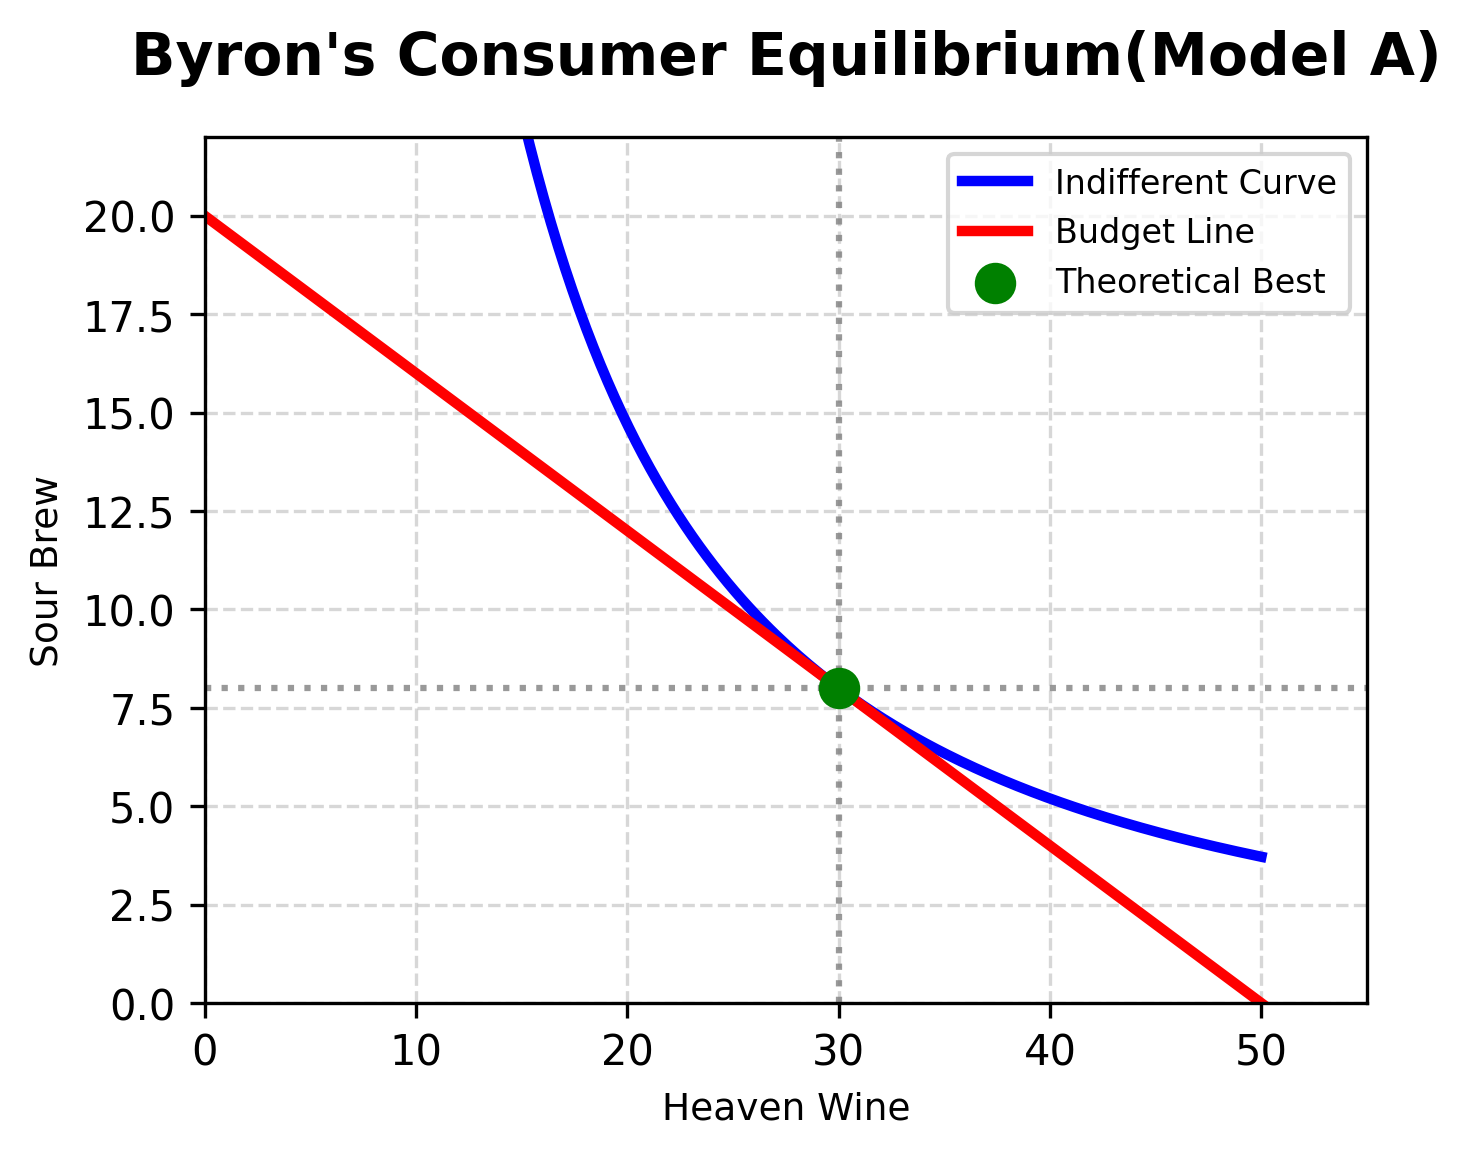

In [ ]:
import matplotlib.pyplot as plt
x_axis=np.linspace(0.0001,budget/heaven,300)
y_ind=(max_u/(x_axis**alpha))**(1/beta)
y_bud=np.clip((budget-(heaven*x_axis))/sour,0,None)
# 幫數據設下限與上限，避免預算線的Y財貨(潤酸釀)出現負數
plt.figure(figsize=(5,3.75),dpi=300)
plt.plot(x_axis,y_ind,label="Indifferent Curve",color="blue",linewidth=2.5)
plt.plot(x_axis,y_bud,label="Budget Line",color="red",linewidth=2.5)
plt.scatter(b_heaven,b_sour,label="Theoretical Best",s=80,zorder=5,color="green")
plt.axhline(y=b_sour,color="gray",linestyle=":",alpha=0.8)
plt.axvline(x=b_heaven,color="gray",linestyle=":",alpha=0.8)
# 在特定位置造出無限延伸的直線，方便對標最適消費組合
plt.title("Byron\'s Consumer Equilibrium(Model A)",fontsize=14,fontweight="bold",pad=15)
# fontweight是字體 bold為粗體 pad為標題和圖表的間距(預設6.0)
plt.xlim(0,budget*1.1/heaven)
plt.ylim(0,budget*1.1/sour)
# 為兩軸保留10%的空間 避免擠到邊緣
plt.xlabel("Heaven Wine",fontsize=9)
plt.ylabel("Sour Brew",fontsize=9)
plt.grid(True,linestyle="--",alpha=0.5)
plt.legend(fontsize=8)
plt.show()